In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
rf_cm = np.array([[446, 12, 8, 94], [5, 506, 0, 49], [8, 21, 511, 20], [29, 18, 15, 498]])
transformer_cm = np.array([[500, 11, 9, 40], [2, 537, 3, 18], [1, 23, 511, 25], [7, 36, 3, 514]])
cnn1d_cm = np.array([[508, 14, 2, 36], [1, 553, 0, 6], [10, 20, 517, 13], [2, 23, 5, 530]])
cnn1dlstm_cm = np.array([[504, 14, 0, 42], [1, 536, 1, 22], [0, 21, 536, 3], [3, 21, 3, 533]])
cnn_cm = np.array([[509, 8, 2, 41], [8, 535, 7, 10], [2, 12, 529, 17], [4, 15, 10, 531]])

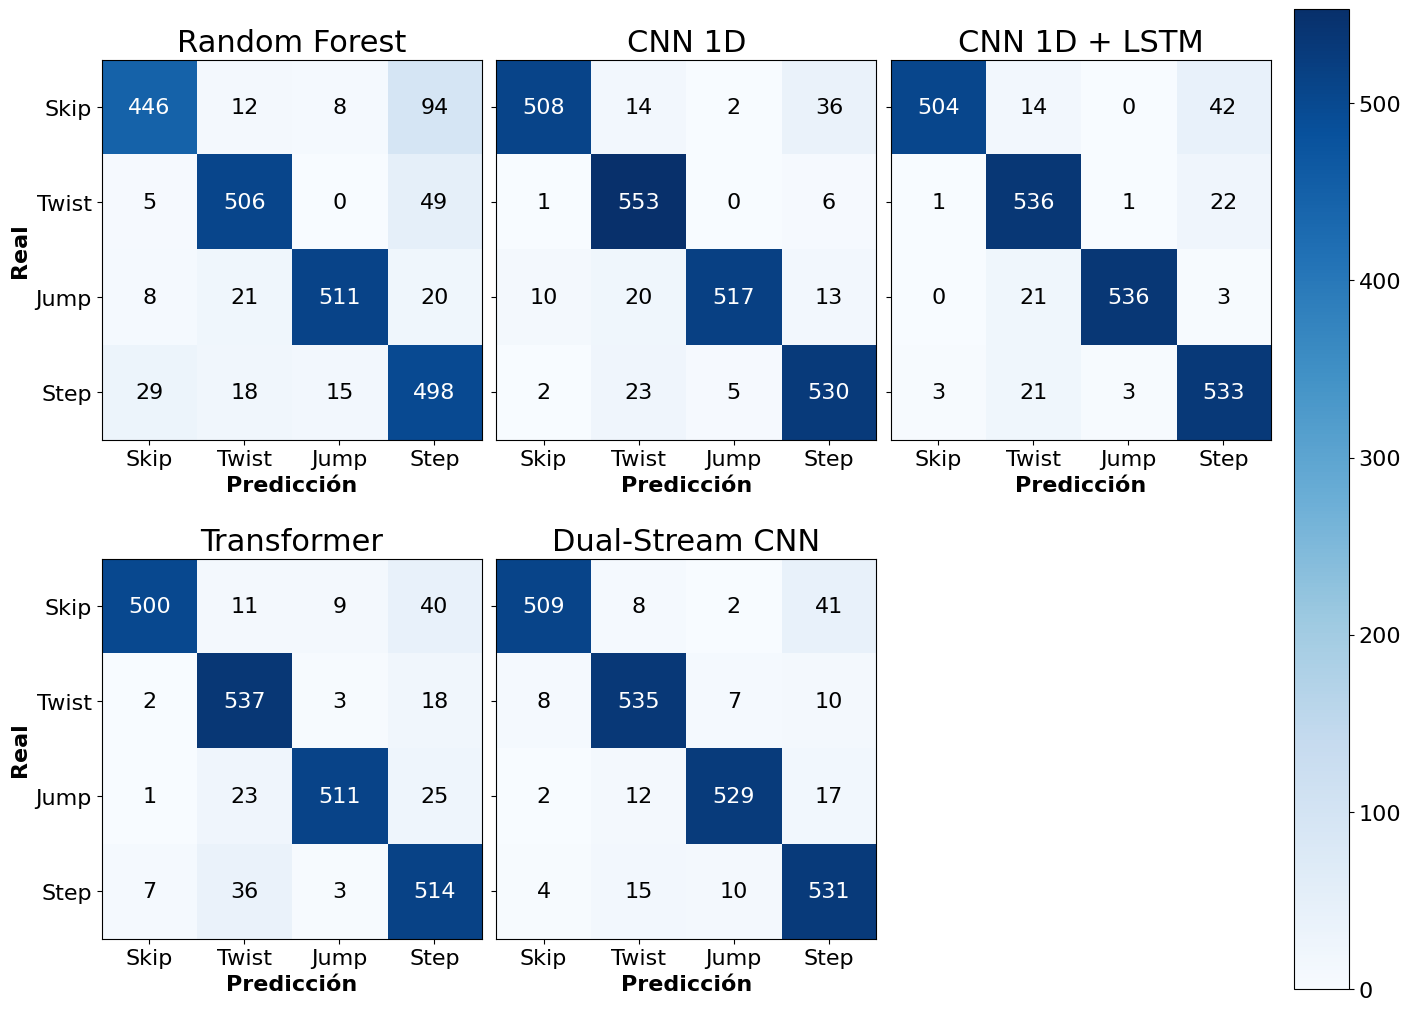

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10), constrained_layout=True, sharey=True)
cms = [rf_cm, cnn1d_cm, cnn1dlstm_cm, transformer_cm, cnn_cm]
titles = ["Random Forest", "CNN 1D", "CNN 1D + LSTM",  "Transformer", "Dual-Stream CNN"]
class_names = ["Skip", "Twist", "Jump", "Step"]

vmin = min(cm.min() for cm in cms)
vmax = max(cm.max() for cm in cms)
threshold = (vmin + vmax) / 2

im = None
for idx, (cm, title) in enumerate(zip(cms, titles)):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    im = ax.imshow(cm, cmap="Blues", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=22)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, fontdict={"fontsize": 16})
    ax.set_yticklabels(class_names, fontdict={"fontsize": 16})
    ax.set_xlabel("Predicción", fontsize=16, fontdict={"fontweight": "bold"})

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "black"
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color=color, fontsize=16)

    if col == 0:
        ax.set_ylabel("Real", fontsize=16, fontdict={"fontweight": "bold"})

if len(cms) < 6:
    axes[1, 2].axis('off')

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.06, pad=0.02, aspect=18)
cbar.ax.tick_params(labelsize=16)

plt.show()

### Visualización logarítmica de las matrices de confusión
A continuación se muestra una versión logarítmica de las matrices de confusión ($\log_{10}(1 + x)$). Esta transformación permite resaltar visualmente los errores menos frecuentes, que en la escala lineal quedarían ocultos por la predominancia de los valores altos en la diagonal principal. Así, es más sencillo detectar de un vistazo en qué clases se producen más errores y comparar la magnitud de las confusiones entre modelos. En cada celda se muestra el valor original y, entre paréntesis, su valor logarítmico.

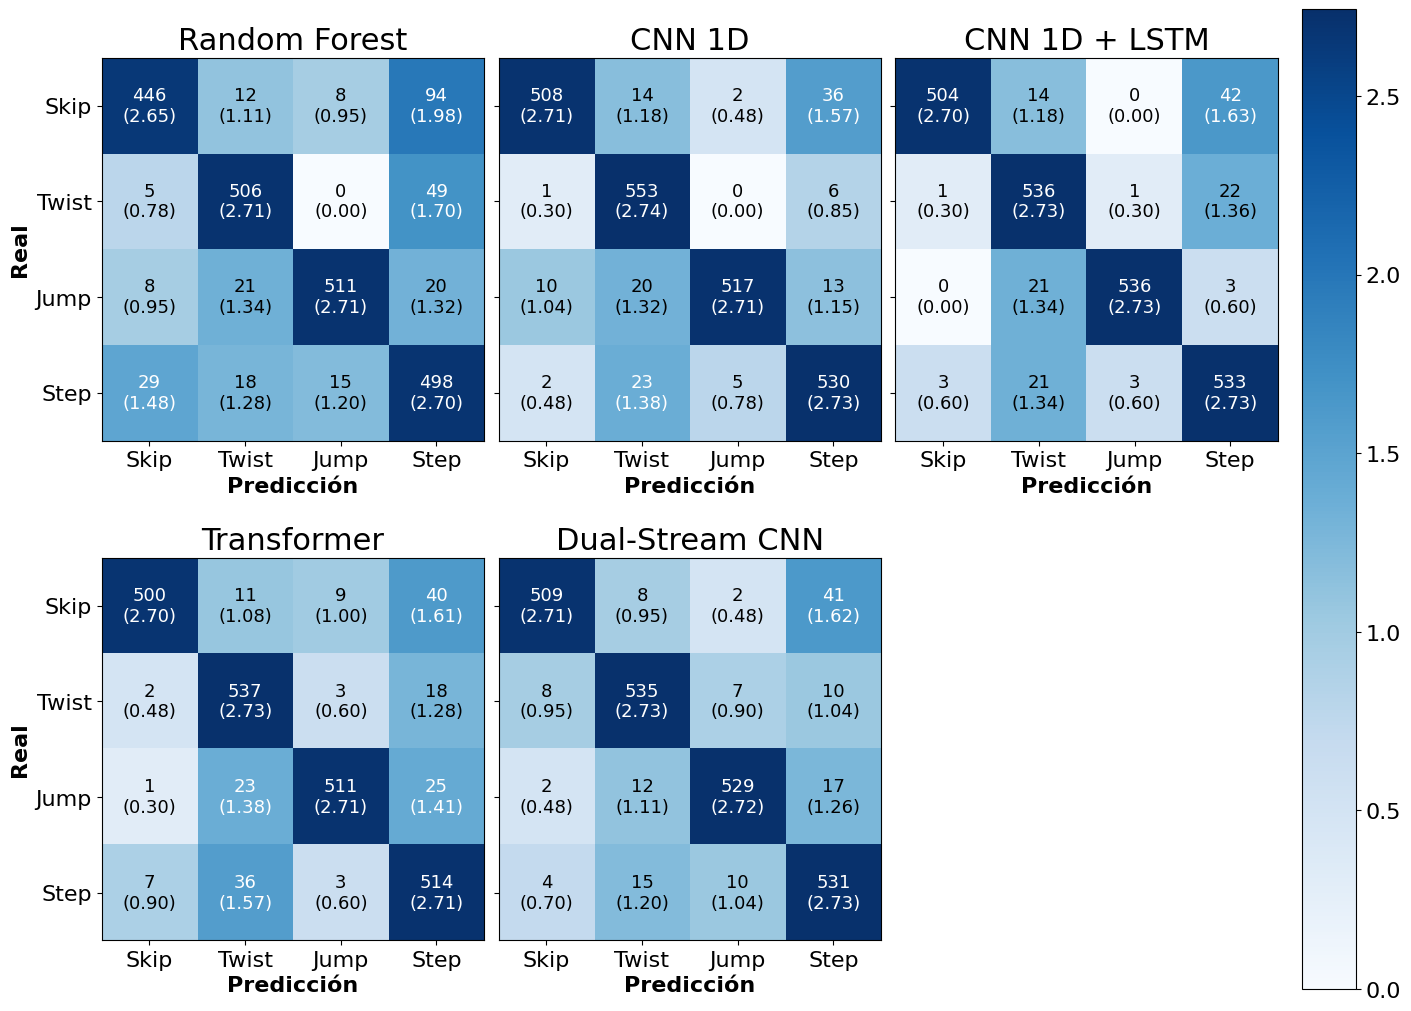

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10), constrained_layout=True, sharey=True)
cms = [rf_cm, cnn1d_cm, cnn1dlstm_cm, transformer_cm, cnn_cm]
titles = ["Random Forest", "CNN 1D", "CNN 1D + LSTM",  "Transformer", "Dual-Stream CNN"]
class_names = ["Skip", "Twist", "Jump", "Step"]

# Aplicamos logaritmo para resaltar errores menos frecuentes
cms_log = [np.log10(cm + 1) for cm in cms]

vmin = min(cm_log.min() for cm_log in cms_log)
vmax = max(cm_log.max() for cm_log in cms_log)
threshold = (vmin + vmax) / 2

im = None
for idx, (cm_log, title) in enumerate(zip(cms_log, titles)):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    im = ax.imshow(cm_log, cmap="Blues", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=22)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, fontdict={"fontsize": 16})
    ax.set_yticklabels(class_names, fontdict={"fontsize": 16})
    ax.set_xlabel("Predicción", fontsize=16, fontdict={"fontweight": "bold"})

    for i in range(cm_log.shape[0]):
        for j in range(cm_log.shape[1]):
            color = "white" if cm_log[i, j] > threshold else "black"
            ax.text(j, i, f"{cms[idx][i, j]}\n({cm_log[i, j]:.2f})", ha="center", va="center", color=color, fontsize=13)

    if col == 0:
        ax.set_ylabel("Real", fontsize=16, fontdict={"fontweight": "bold"})

if len(cms) < 6:
    axes[1, 2].axis('off')

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.06, pad=0.02, aspect=18)
cbar.ax.tick_params(labelsize=16)

plt.show()

In [6]:
rf_report = {'acc': 0.8754, 'precision_macro': 0.8800, 'recall_macro': 0.8800, 'f1_macro': 0.8800}
transformer_report = {'acc': 0.920536, 'precision_macro': 0.924381, 'recall_macro': 0.920536, 'f1_macro': 0.921115}
cnn1d_report = {'acc': 0.941071, 'precision_macro': 0.943557, 'recall_macro': 0.941071, 'f1_macro': 0.941202}
cnn1dlstm_report = {'acc': 0.943214, 'precision_macro': 0.944801, 'recall_macro': 0.943214, 'f1_macro': 0.943601}
cnn_report = {'acc': 0.939286, 'precision_macro': 0.940908, 'recall_macro': 0.939286, 'f1_macro': 0.939516}

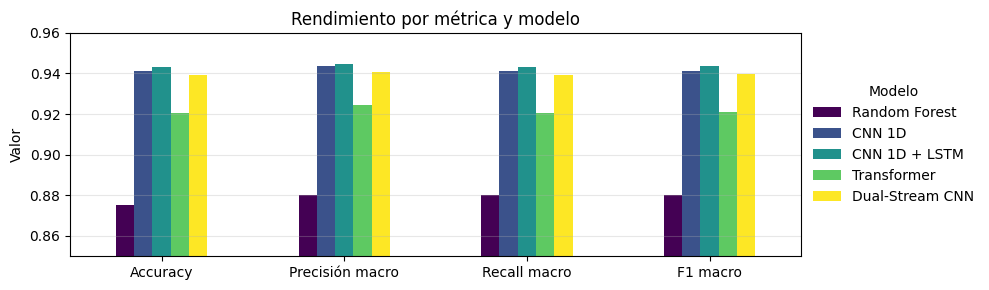

In [ ]:
metrics = {
    'Random Forest': rf_report,
    'CNN 1D': cnn1d_report,
    'CNN 1D + LSTM': cnn1dlstm_report,
    'Transformer': transformer_report,
    'Dual-Stream CNN': cnn_report
}

metrics_df = pd.DataFrame(metrics).T

metrics_df = metrics_df[['acc', 'precision_macro', 'recall_macro', 'f1_macro']]
metrics_df.columns = ['Accuracy', 'Precisión macro', 'Recall macro', 'F1 macro']
ax = metrics_df.T.plot(kind='bar', figsize=(10, 3), rot=0, colormap='viridis')
plt.ylim(0.85, 0.96)
plt.ylabel('Valor')
plt.title('Rendimiento por métrica y modelo')
leg = plt.legend(title='Modelo', loc='center left', bbox_to_anchor=(1, 0.5))
leg.get_frame().set_linewidth(0)
leg.get_frame().set_edgecolor('none')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()